<a href="https://colab.research.google.com/github/ibrahim0015/Internship/blob/main/Neural%20Networks/Rice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip rice_data.zip


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),  # 64 -> 32 -> 16 -> 8 after 3 MaxPools
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

In [16]:
def get_dataloaders(batch_size=32, test_split=0.2):
    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(64, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    full_dataset = ImageFolder(root="/content/Rice_Image_Dataset")

    total_size = len(full_dataset)
    test_size = int(test_split * total_size)
    train_size = total_size - test_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    # Apply separate transforms after splitting
    train_dataset.dataset.transform = train_transform
    test_dataset.dataset.transform = test_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"Classes:        {full_dataset.classes}")
    print(f"Total images:   {total_size}")
    print(f"Training set:   {train_size}")
    print(f"Test set:       {test_size}")

    return train_loader, test_loader


In [17]:
def train_model(model, train_loader, criterion, optimizer, scheduler, epochs=20):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        avg_loss  = running_loss / len(train_loader)

        scheduler.step()  # Decay LR every step_size epochs

        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.4f}  Train Acc: {train_acc:.2f}%")


In [18]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=32)

model     = SimpleCNN(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("\nStarting training...")
train_model(model, train_loader, criterion, optimizer, scheduler, epochs=20)

print("\nEvaluating on test set...")
evaluate_model(model, test_loader)

Using device: cuda
Classes:        ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Total images:   75000
Training set:   60000
Test set:       15000

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/20]  Loss: 0.1283  Train Acc: 95.82%
Epoch [2/20]  Loss: 0.0633  Train Acc: 98.08%
Epoch [3/20]  Loss: 0.0437  Train Acc: 98.70%
Epoch [4/20]  Loss: 0.0344  Train Acc: 98.94%
Epoch [5/20]  Loss: 0.0300  Train Acc: 99.12%
Epoch [6/20]  Loss: 0.0147  Train Acc: 99.58%
Epoch [7/20]  Loss: 0.0131  Train Acc: 99.65%
Epoch [8/20]  Loss: 0.0129  Train Acc: 99.64%
Epoch [9/20]  Loss: 0.0129  Train Acc: 99.65%
Epoch [10/20]  Loss: 0.0102  Train Acc: 99.72%
Epoch [11/20]  Loss: 0.0061  Train Acc: 99.83%
Epoch [12/20]  Loss: 0.0047  Train Acc: 99.87%
Epoch [13/20]  Loss: 0.0055  Train Acc: 99.86%
Epoch [14/20]  Loss: 0.0043  Train Acc: 99.88%
Epoch [15/20]  Loss: 0.0042  Train Acc: 99.86%
Epoch [16/20]  Loss: 0.0028  Train Acc: 99.93%
Epoch [17/20]  Loss: 0.0027  Train Acc: 99.92%
Epoch [18/20]  Loss: 0.0032  Train Acc: 99.92%
Epoch [19/20]  Loss: 0.0027  Train Acc: 99.91%
Epoch [20/20]  Loss: 0.0021  Train Acc: 99.95%

Evaluating on test set...
Test Accuracy: 99.93%


Activation map shape: torch.Size([64, 32, 32])


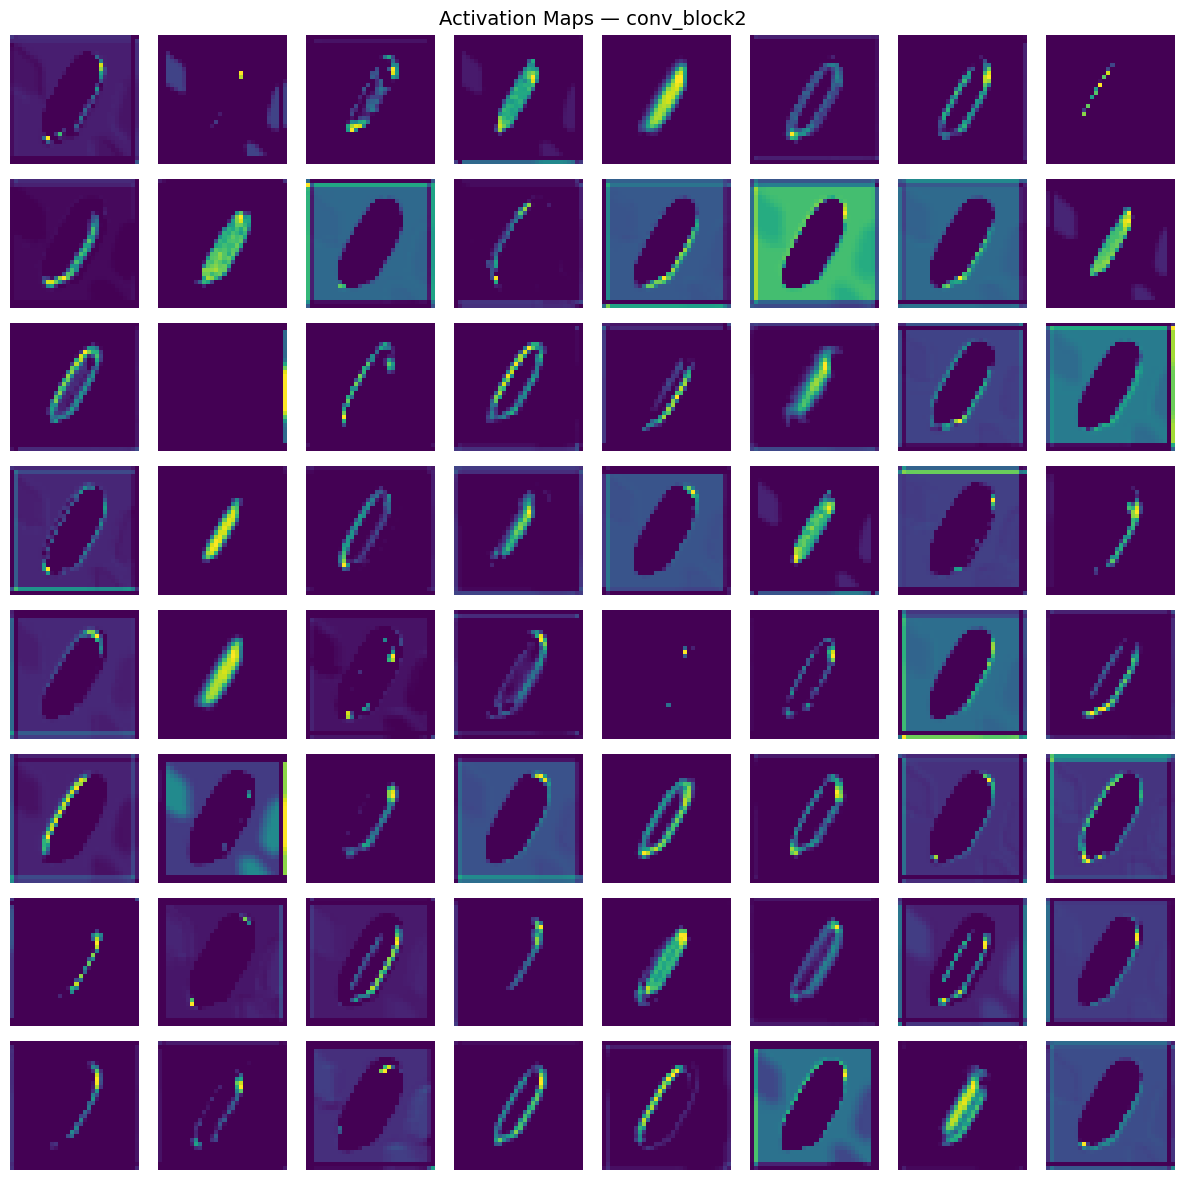

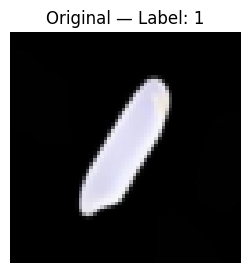

In [28]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Hook to capture activation
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Register hook on the layer

model.conv_block2[0].register_forward_hook(get_activation('conv_block2'))

# Forward pass a single image
model.eval()
images, labels = next(iter(test_loader))   # grab one batch
single_image = images[0].unsqueeze(0).to(device)  # shape: (1, 3, 64, 64)

with torch.no_grad():
    output = model(single_image)

# Plot the activation maps
act = activation['conv_block2'].squeeze(0)
print(f"Activation map shape: {act.shape}")

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i].cpu(), cmap='viridis')
    ax.axis('off')

plt.suptitle('Activation Maps — conv_block2', fontsize=14)
plt.tight_layout()
plt.show()

# original image for comparison
original = single_image.squeeze(0).cpu().permute(1, 2, 0).numpy()
original = (original * 0.5) + 0.5
plt.figure(figsize=(3, 3))
plt.imshow(original)
plt.title(f"Original — Label: {labels[0].item()}")
plt.axis('off')
plt.show()